In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


# **Preprocessing**

In [2]:
df = pd.read_csv('cleaned_laptop_dataset_2.csv')

In [3]:
df.shape

(3719, 14)

In [4]:
df.isnull().sum()

Brand                   0
Price                   0
Processor_Brand         0
RAM_Expandable          0
RAM_Capacity            0
RAM_TYPE(DDR)           0
Processor_Speed(Ghz)    0
Display_type            0
GPU_Brand               0
SSD(GB)                 0
HDD(GB)                 0
Processor_Category      0
Display_Tier            0
GPU_Tier                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3719 entries, 0 to 3718
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Brand                 3719 non-null   object 
 1   Price                 3719 non-null   float64
 2   Processor_Brand       3719 non-null   object 
 3   RAM_Expandable        3719 non-null   object 
 4   RAM_Capacity          3719 non-null   int64  
 5   RAM_TYPE(DDR)         3719 non-null   object 
 6   Processor_Speed(Ghz)  3719 non-null   float64
 7   Display_type          3719 non-null   object 
 8   GPU_Brand             3719 non-null   object 
 9   SSD(GB)               3719 non-null   int64  
 10  HDD(GB)               3719 non-null   int64  
 11  Processor_Category    3719 non-null   object 
 12  Display_Tier          3719 non-null   object 
 13  GPU_Tier              3719 non-null   object 
dtypes: float64(2), int64(3), object(9)
memory usage: 406.9+ KB


In [6]:
# df['Processor_Brand'] = df['Processor_Brand'].astype('category')
# df['Processor_Category'] = df['Processor_Category'].astype('category')
# # df['Processor_Tier'] = df['Processor_Tier'].astype('category')
# df['GPU_Brand'] = df['GPU_Brand'].astype('category')
# df['GPU_Tier'] = df['GPU_Tier'].astype('category')
# df['RAM_TYPE(DDR)'] = df['RAM_TYPE(DDR)'].astype('category')
# df['Display_type'] = df['Display_type'].astype('category')
# df['Display_Tier'] = df['Display_Tier'].astype('category')
# df['RAM_Expandable'] = df['RAM_Expandable'].astype('category')


In [7]:
# Categorical columns
categorical_cols = df.select_dtypes(include=['category']).columns
print("Categorical columns:", list(categorical_cols))

# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", list(numerical_cols))

Categorical columns: []
Numerical columns: ['Price', 'RAM_Capacity', 'Processor_Speed(Ghz)', 'SSD(GB)', 'HDD(GB)']


In [8]:
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")
    print(f"{df[col].value_counts()}\n")

## **Encode Categorical Columns**

In [9]:

from sklearn.preprocessing import LabelEncoder

# Binary columns
df["RAM_Expandable"] = df["RAM_Expandable"].map({"Yes": 1, "No": 0})
df["Display_type"] = df["Display_type"].map({"LED": 1, "LCD": 0})

# Ordinal columns
df['Display_Tier'] = df['Display_Tier'].map({
    'Small': 1, 'Medium': 2, 'Large': 3
})
df['GPU_Tier'] = df['GPU_Tier'].map({
    'Entry-level': 1, 'Low-end': 2, 'Mid-end': 3, 'High-end': 4
})

df['RAM_TYPE(DDR)'] = df['RAM_TYPE(DDR)'].map({
    '3': 1, 'LP3': 2,
    '4': 3, 'LP4': 4,
    '5': 5, 'LP5': 6
})

# One-Hot Encoding for nominal columns

df= pd.get_dummies(
    df, 
    columns=['Processor_Category', 'Brand', 'Processor_Brand', 'GPU_Brand'],
    drop_first=True # keep all categories
)


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3719 entries, 0 to 3718
Data columns (total 40 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Price                              3719 non-null   float64
 1   RAM_Expandable                     3719 non-null   int64  
 2   RAM_Capacity                       3719 non-null   int64  
 3   RAM_TYPE(DDR)                      3719 non-null   int64  
 4   Processor_Speed(Ghz)               3719 non-null   float64
 5   Display_type                       3719 non-null   int64  
 6   SSD(GB)                            3719 non-null   int64  
 7   HDD(GB)                            3719 non-null   int64  
 8   Display_Tier                       3719 non-null   int64  
 9   GPU_Tier                           3719 non-null   int64  
 10  Processor_Category_AMD Athlon      3719 non-null   bool   
 11  Processor_Category_AMD Other       3719 non-null   bool 

In [11]:
df.head()

,Price,RAM_Expandable,RAM_Capacity,RAM_TYPE(DDR),Processor_Speed(Ghz),Display_type,SSD(GB),HDD(GB),Display_Tier,GPU_Tier,...,Brand_HP,Brand_Lenovo,Brand_MSI,Brand_Other,Brand_Samsung,Processor_Brand_Apple,Processor_Brand_Intel,GPU_Brand_Apple,GPU_Brand_Intel,GPU_Brand_NVIDIA
0,127011.5,1,8,3,4.0,0,512,0,1,2,...,False,True,False,False,False,False,False,False,False,False
1,274750.0,1,16,5,3.5,0,512,0,1,3,...,False,False,False,False,False,False,True,False,False,True
2,194215.0,1,8,3,4.0,0,512,0,1,1,...,True,False,False,False,False,False,True,False,True,False
3,76965.0,0,8,4,1.5,0,512,0,1,1,...,False,False,False,True,False,False,True,False,True,False
4,122465.0,1,16,3,2.5,0,512,0,1,1,...,False,False,False,False,False,False,True,False,True,False


## **Heatmap**

In [12]:
#Separate features and target
feature_cols = [col for col in df.columns if col != 'Price'] 
X = df[feature_cols]  # 23 features
y = df['Price']       # 1 target

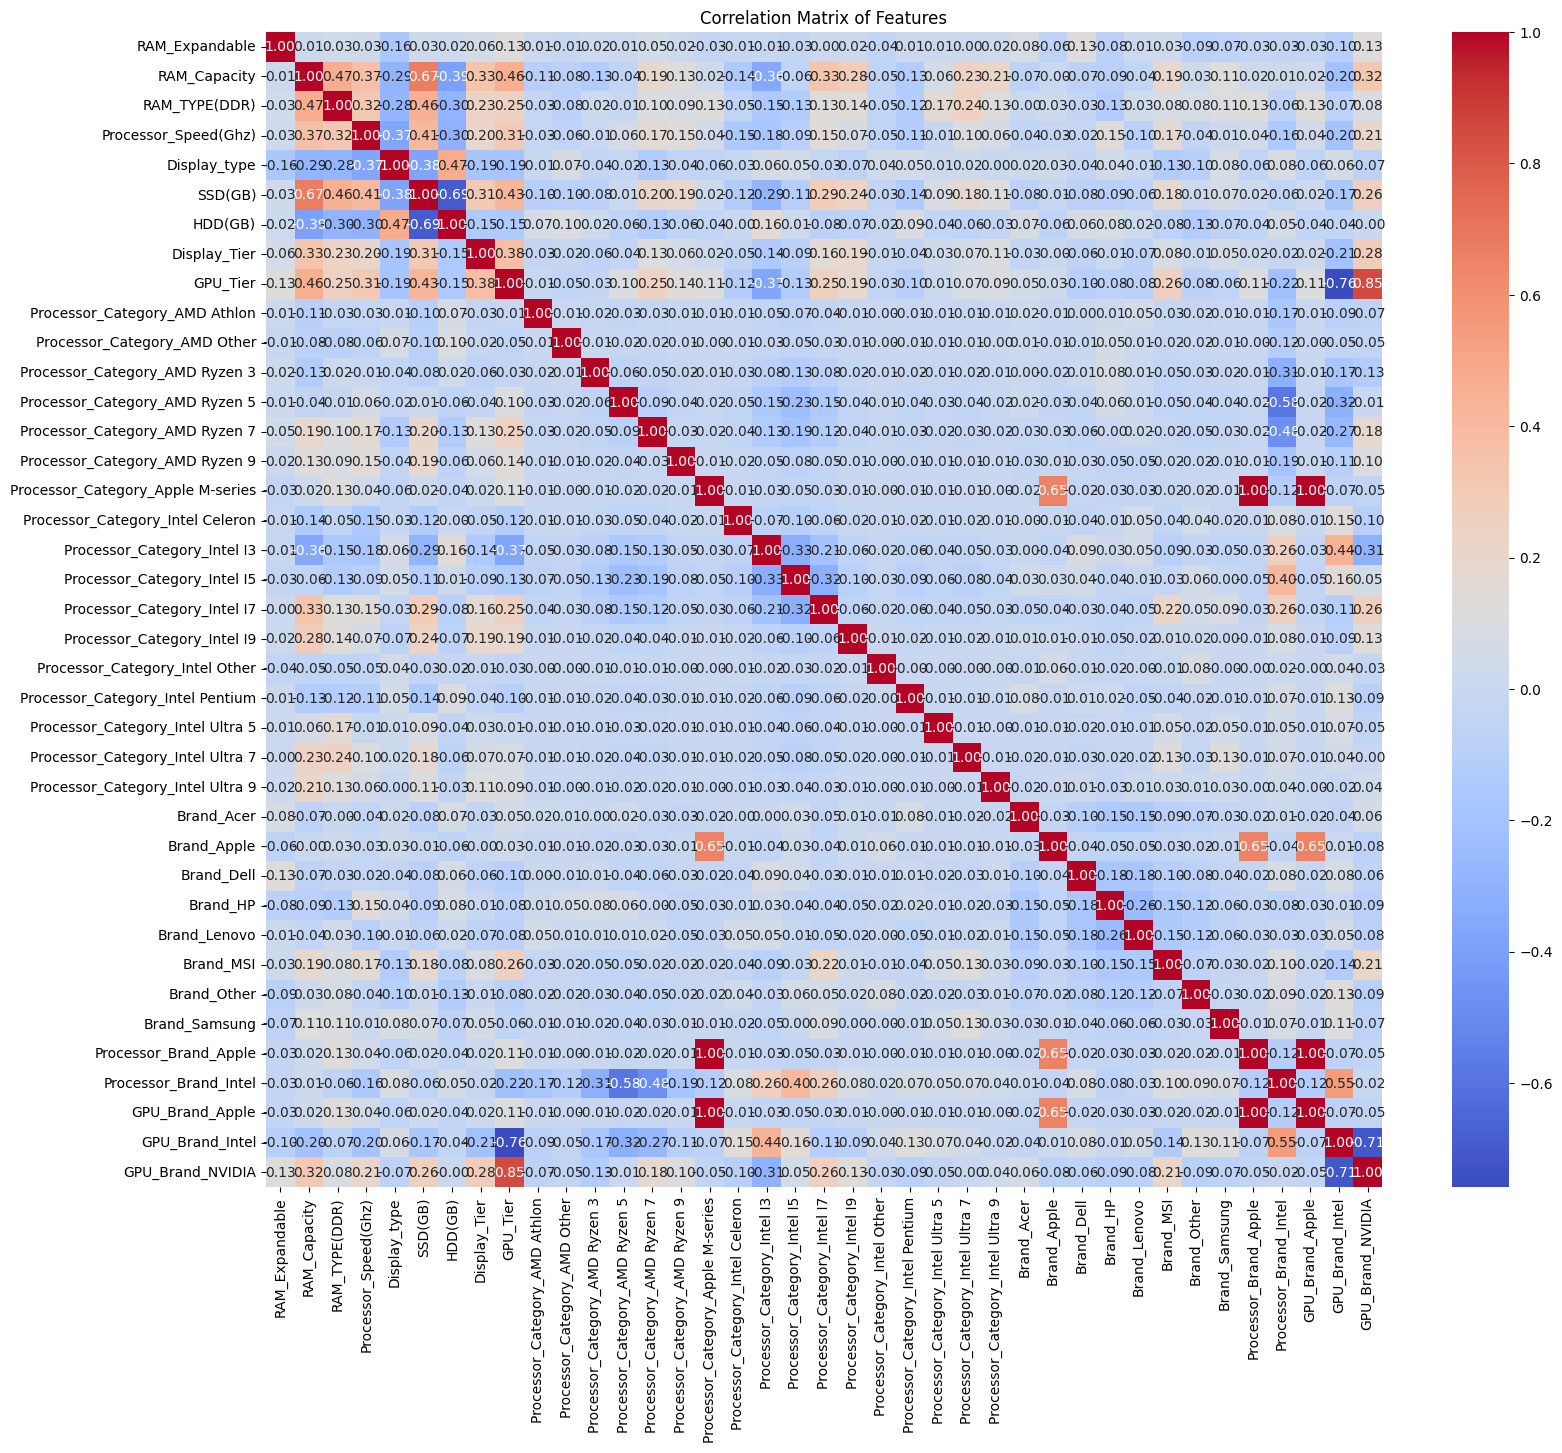

In [13]:
plt.figure(figsize=(18,15))
sns.heatmap(X.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Features")
plt.show()

In [14]:
import numpy as np

X_vif = X.copy()
# Remove rows with NaN or Inf values
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)  # replace infs with NaN
X_vif = X_vif.dropna()  # drop rows with NaN values


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np


# Keep only numeric columns
X_vif = X_vif.select_dtypes(include=['int64', 'float64', 'category'])

# Handle missing and infinite values
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)
X_vif = X_vif.dropna()

# Compute VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))


                Feature        VIF
2         RAM_TYPE(DDR)  11.660327
5               SSD(GB)  10.851370
1          RAM_Capacity  10.048702
3  Processor_Speed(Ghz)   8.198713
8              GPU_Tier   6.266647
7          Display_Tier   5.856658
6               HDD(GB)   2.889134
4          Display_type   2.294808
0        RAM_Expandable   1.877682


# Model Development

### **Split Features and Target**

In [16]:
X = df.drop('Price', axis=1)
y = df['Price']

### **Train-Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Feature Scaling

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Train Random Forest Regressor

In [19]:
baseline_model = RandomForestRegressor(random_state=42)
# baseline_model.fit(X_train, y_train)
baseline_model.fit(X_train_scaled, y_train)

y_pred = baseline_model.predict(X_test_scaled)
# y_pred = baseline_model.predict(X_test)

print("----- Baseline Model -----")
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))



----- Baseline Model -----
R² Score: 0.7580620223027486
MAE: 45863.58586602328
RMSE: 74283.86738970308


In [20]:
from sklearn.model_selection import RandomizedSearchCV


# Define the parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(
    estimator=baseline_model,
    param_distributions=param_dist,
    n_iter=50,                 # number of random combinations to try
    cv=5,                      # 5-fold cross-validation
    scoring='r2',              # optimize R² score
    n_jobs=-1,                 # use all CPU cores
    verbose=2,
    random_state=42
)

#Fit on training data
random_search.fit(X_train_scaled, y_train)
# random_search.fit(X_train, y_train)

#Get the best model and parameters
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation R²:", random_search.best_score_)





Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.5s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END bootstrap=True, max_depth=40, max_features=sqrt, min_samples_leaf=2, min_samples_split=10, n_estimators=300; total time=   1.6s
[CV] END bootstrap=False, max_depth=50, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   1.7s
[CV] END bootstrap=False, max_depth=50, max_features=log2, min_samples_leaf=4, min_samples_split=10, n_estimators=300; total time=   1.8s
[CV] END bootstrap=True, max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; 

In [21]:

best_rf = random_search.best_estimator_

# --- 6. Evaluate on test data ---
y_pred = best_rf.predict(X_test_scaled)
# y_pred = best_rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n----- Tuned Random Forest Performance - Randomized search -----")
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)



----- Tuned Random Forest Performance - Randomized search -----
R² Score: 0.767443269899944
MAE: 44626.255278169825
RMSE: 72829.43472239753


In [22]:
param_grid = {
    'n_estimators': [400, 500, 600],
    'max_depth': [20,30, 40, 50],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}
# param_grid = {
#     'n_estimators': [200, 300, 400],
#     'max_depth': [30, 40, 50],
#     'min_samples_split': [2, 3, 5],
#     'min_samples_leaf': [1, 2],
#     'max_features': ['log2']
# }
# param_grid = {
#     'n_estimators': [200, 300, 400],
#     'max_depth': [30, 40, 50, None],
#     'min_samples_split': [2, 3, 5],
#     'min_samples_leaf': [1, 2],
#     'max_features': ['sqrt']
# }
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=5,             # 5-fold cross-validation
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)
# grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best CV R² Score:", grid_search.best_score_)
best_rf = grid_search.best_estimator_
best_rf.fit(X_train_scaled, y_train)
# best_rf.fit(X_train, y_train)

y_pred_best = best_rf.predict(X_test_scaled)
# y_pred_best = best_rf.predict(X_test)
print("\n----- Final Tuned Model-----")
print("R² Score:", r2_score(y_test, y_pred_best))
print("MAE:", mean_absolute_error(y_test, y_pred_best))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best)))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=3, n_estimators=400; total time=   2.8s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=3, n_estimators=400; total time=   2.9s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=3, n_estimators=400; total time=   3.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=3, n_estimators=400; total time=   3.1s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=3, n_estimators=400; total time=   4.9s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   5.8s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=400; total time=   5.9s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=40

In [23]:
average_price = df["Price"].mean()
print("Average Laptop Price:", average_price)

MAE = 44227.24  # your model's MAE value
relative_error = (MAE / average_price) * 100
print(f"Average Laptop Price: {average_price:.2f}")
print(f"Relative Error: {relative_error:.2f}%")


Average Laptop Price: 248431.05122344717
Average Laptop Price: 248431.05
Relative Error: 17.80%


On average, this random forest model's predictions are within ~17% of the true price

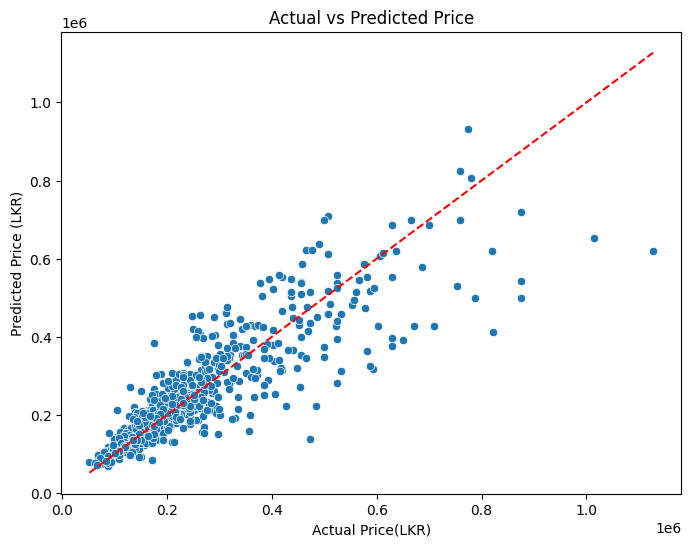

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price(LKR)")
plt.ylabel("Predicted Price (LKR)")
plt.title("Actual vs Predicted Price")
plt.show()

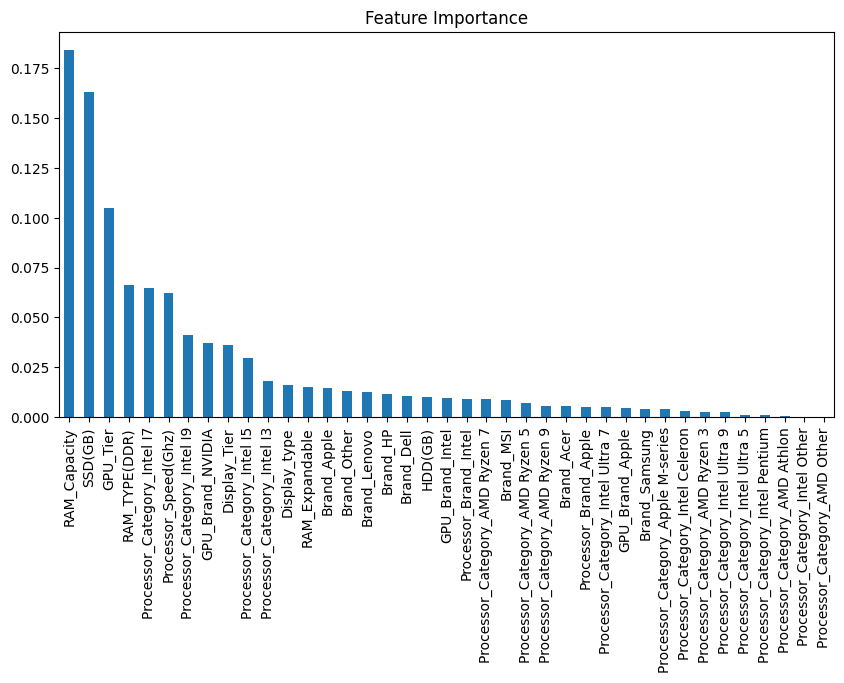

In [25]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()


In [26]:
import joblib
joblib.dump(best_rf, "final_rf_model.pkl")
print("Model saved successfully!")


Model saved successfully!
